# ✈️ CO2 Emissions from Aviation — Enhanced ML & Forecasting Pipeline

**SkyInsight | ESPRIT 3ALINFO **

## Enhanced Workflow
1. Setup & Imports  
2. Data Loading  
3. Data Understanding  
4. Data Cleaning  
5. Exploratory Data Analysis (EDA)  
6. Advanced Feature Engineering  
7. Time-Based Data Preparation  
8. Multi-Model Training & Tuning  
   - Linear Regression (baseline)  
   - Lasso & ElasticNet (regularized)  
   - Random Forest (tuned)  
   - XGBoost (if available)  
   - LightGBM (if available)  
   - SVR  
   - Prophet (if available)  
9. Evaluation & Model Comparison  
10. Ensemble  
11. 10-Year Forecasting  
12. Anomaly Detection  
13. Feature Importance  
14. Multi-Country Comparison  
15. Insights & Conclusion  

In [1]:
# ═══════════════════════════════════════════════════════════
# 1) SETUP & IMPORTS
# ═══════════════════════════════════════════════════════════
import os
import warnings
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# --- Sklearn ---
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
 )

# --- Statsmodels ---
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# --- Optional: Prophet ---
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except Exception:
    PROPHET_AVAILABLE = False

# --- Optional: XGBoost ---
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

# --- Optional: LightGBM ---
try:
    from lightgbm import LGBMRegressor
    LGBM_AVAILABLE = True
except Exception:
    LGBM_AVAILABLE = False

warnings.filterwarnings("ignore")

# Styling
sns.set_theme(style="whitegrid", context="talk", palette="husl")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
COLORS = sns.color_palette("husl", 12)

print(f"Prophet   available: {PROPHET_AVAILABLE}")
print(f"XGBoost   available: {XGBOOST_AVAILABLE}")
print(f"LightGBM  available: {LGBM_AVAILABLE}")
print("Setup complete ✅")

Prophet   available: False
XGBoost   available: True
LightGBM  available: True
Setup complete ✅


In [2]:
# ═══════════════════════════════════════════════════════════
# 2) DATA LOADING
# ═══════════════════════════════════════════════════════════
DATA_PATH = "annual-co-emissions-from-aviation.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at '{DATA_PATH}'.\n"
        "Place the notebook in the same folder as the CSV, or update DATA_PATH."
    )

df_raw = pd.read_csv(DATA_PATH)

print("First 5 rows:")
display(df_raw.head())
print(f"\nDataset shape: {df_raw.shape}")
print("Columns:", df_raw.columns.tolist())

First 5 rows:


,Entity,Code,Year,Total annual CO₂ emissions from aviation
0,Afghanistan,AFG,2013,208656.12
1,Afghanistan,AFG,2014,227078.30
2,Afghanistan,AFG,2015,187643.45
3,Afghanistan,AFG,2016,177195.73
4,Afghanistan,AFG,2017,204241.47



Dataset shape: (1605, 4)
Columns: ['Entity', 'Code', 'Year', 'Total annual CO₂ emissions from aviation']


In [3]:
# ═══════════════════════════════════════════════════════════
# 3) DATA UNDERSTANDING
# ═══════════════════════════════════════════════════════════
print("Data types:")
display(df_raw.dtypes.to_frame("dtype"))

print("\nSummary statistics:")
display(df_raw.describe(include="all").T)

print("\nMissing values per column:")
missing_df = df_raw.isna().sum().to_frame("missing_count")
missing_df["missing_pct"] = (missing_df["missing_count"] / len(df_raw) * 100).round(2)
display(missing_df.sort_values("missing_count", ascending=False))

Data types:


,dtype
Entity,object
Code,object
Year,int64
Total annual CO₂ emissions from aviation,float64



Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Entity,1605,171,Africa,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Code,1599,170,OWID_AFR,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,1605.0,NaN,NaN,NaN,2018.257944,3.460249,2013.0,2015.0,2018.0,2021.0,2024.0
Total annual CO₂ emissions from aviation,1605.0,NaN,NaN,NaN,14209594.177289,59769910.890148,2929.3525,205469.61,875032.3,4384410.0,863242600.0



Missing values per column:


,missing_count,missing_pct
Code,6,0.37
Entity,0,0.00
Year,0,0.00
Total annual CO₂ emissions from aviation,0,0.00


In [4]:
# ═══════════════════════════════════════════════════════════
# 4) DATA CLEANING
# ═══════════════════════════════════════════════════════════
def clean_emissions_data(df: pd.DataFrame) -> pd.DataFrame:
    """Clean and standardize the raw emissions dataframe."""
    cleaned = df.copy()

    rename_map = {
        "Entity": "Country",
        "Code": "CountryCode",
        "Year": "Year",
        "Total annual CO2 emissions from aviation": "Emissions",
        "Total annual CO\u2082 emissions from aviation": "Emissions",
    }
    cleaned = cleaned.rename(columns=rename_map)

    required_cols = ["Country", "Year", "Emissions"]
    missing_required = [c for c in required_cols if c not in cleaned.columns]
    if missing_required:
        raise ValueError(f"Missing required columns after rename: {missing_required}")

    cleaned["Country"] = cleaned["Country"].astype(str).str.strip()
    cleaned["Year"] = pd.to_numeric(cleaned["Year"], errors="coerce")
    cleaned["Emissions"] = pd.to_numeric(cleaned["Emissions"], errors="coerce")

    cleaned = cleaned.dropna(subset=["Country", "Year", "Emissions"]).copy()
    cleaned["Year"] = cleaned["Year"].astype(int)

    cleaned = cleaned.drop_duplicates(subset=["Country", "Year"], keep="last")
    cleaned = cleaned.sort_values(["Country", "Year"]).reset_index(drop=True)

    return cleaned

df = clean_emissions_data(df_raw)
print(f"Cleaned shape: {df.shape}")
display(df.head())

Cleaned shape: (1605, 4)


,Country,CountryCode,Year,Emissions
0,Afghanistan,AFG,2013,208656.12
1,Afghanistan,AFG,2014,227078.30
2,Afghanistan,AFG,2015,187643.45
3,Afghanistan,AFG,2016,177195.73
4,Afghanistan,AFG,2017,204241.47


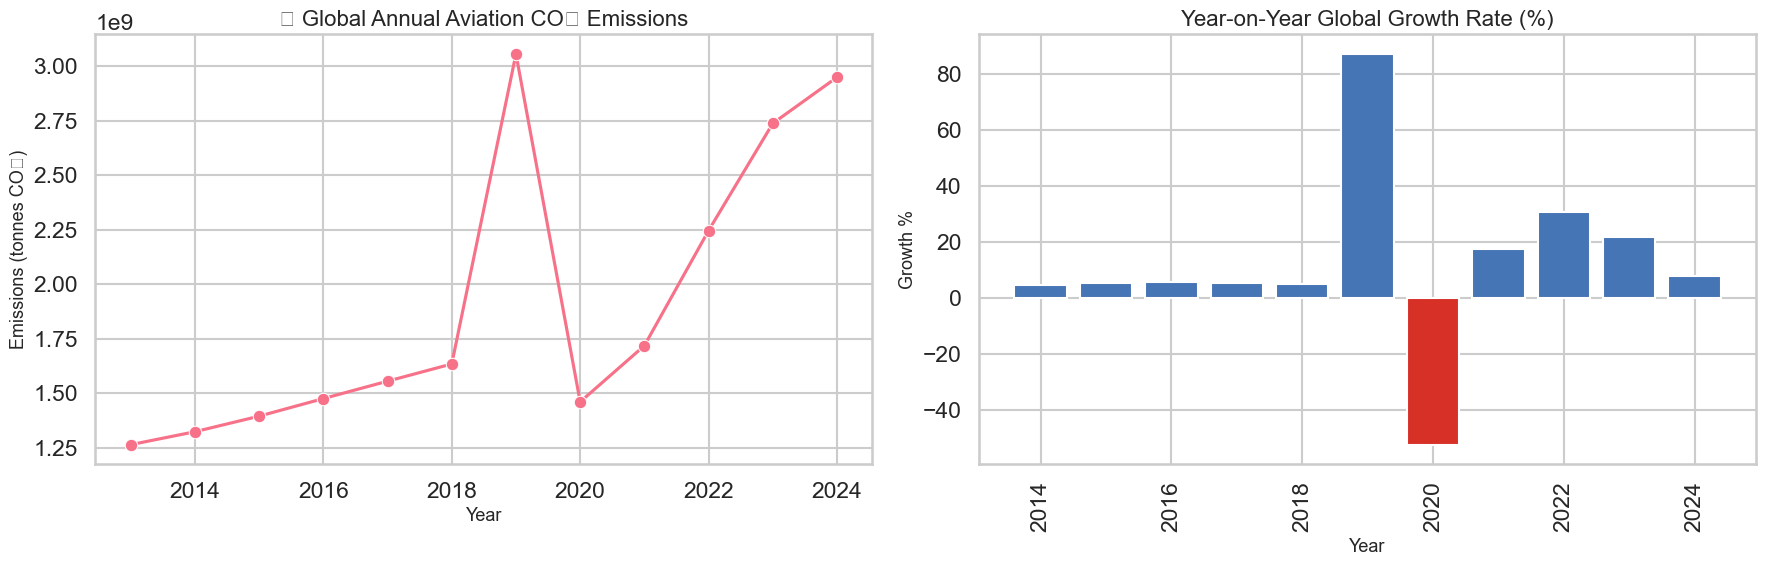

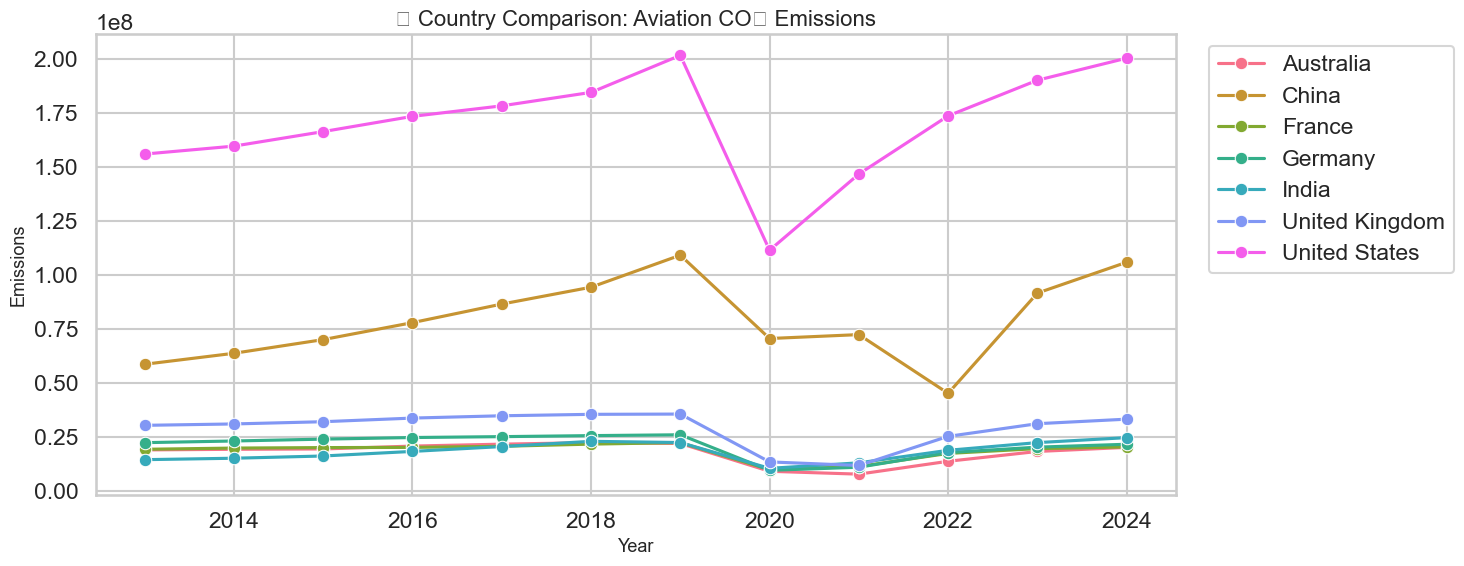

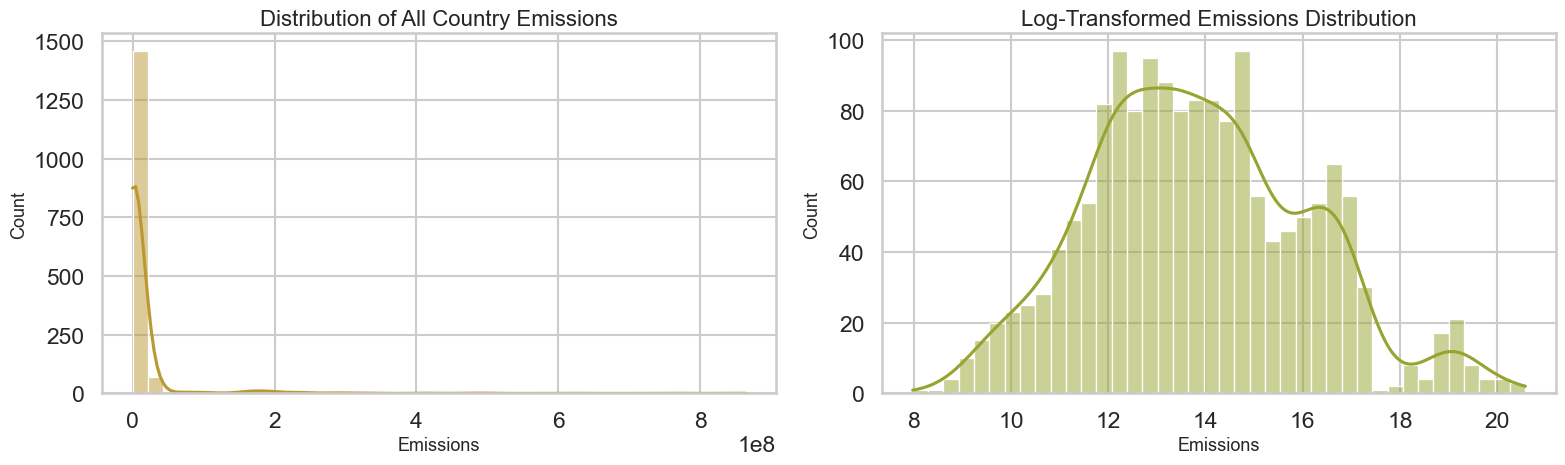


📊 Summary Stats (Global):


,Year,Emissions
count,12.000000,1.200000e+01
mean,2018.500000,1.900533e+09
std,3.605551,6.638232e+08
min,2013.000000,1.263311e+09
25%,2015.750000,1.443275e+09
50%,2018.500000,1.594026e+09
75%,2021.250000,2.368326e+09
max,2024.000000,3.055384e+09


In [5]:
# ═══════════════════════════════════════════════════════════
# 5) EXPLORATORY DATA ANALYSIS (EDA)
# ═══════════════════════════════════════════════════════════

# --- 5a) Global Annual Trend ---
global_by_year = df.groupby("Year", as_index=False)["Emissions"].sum()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.lineplot(ax=axes[0], data=global_by_year, x="Year", y="Emissions", marker="o", color=COLORS[0])
axes[0].set_title("🌍 Global Annual Aviation CO₂ Emissions")
axes[0].set_ylabel("Emissions (tonnes CO₂)")

# Growth rate
bars_df = global_by_year.copy()
bars_df["Growth_pct"] = bars_df["Emissions"].pct_change() * 100
bars_df = bars_df.dropna()

bar_colors = ["#d73027" if v < 0 else "#4575b4" for v in bars_df["Growth_pct"]]
axes[1].bar(bars_df["Year"].astype(int), bars_df["Growth_pct"], color=bar_colors)
axes[1].set_title("Year-on-Year Global Growth Rate (%)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Growth %")

# Reduce tick density for faster rendering
if len(bars_df) > 20:
    step = max(1, len(bars_df) // 10)
    axes[1].set_xticks(bars_df["Year"].astype(int).iloc[::step])

axes[1].tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

# --- 5b) Top Countries ---
preferred = ["United States", "China", "India", "United Kingdom", "Germany", "France", "Australia"]
available = [c for c in preferred if c in df["Country"].unique()]
if len(available) < 3:
    available = (
        df.groupby("Country")["Emissions"].mean()
        .sort_values(ascending=False).head(6).index.tolist()
    )

subset = df[df["Country"].isin(available)].copy()
plt.figure(figsize=(15, 6))
sns.lineplot(data=subset, x="Year", y="Emissions", hue="Country", marker="o")
plt.title("🛫 Country Comparison: Aviation CO₂ Emissions")
plt.ylabel("Emissions")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# --- 5c) Distribution of Emissions ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df["Emissions"], bins=40, kde=True, ax=axes[0], color=COLORS[2])
axes[0].set_title("Distribution of All Country Emissions")
sns.histplot(np.log1p(df["Emissions"]), bins=40, kde=True, ax=axes[1], color=COLORS[3])
axes[1].set_title("Log-Transformed Emissions Distribution")
plt.tight_layout()
plt.show()

# --- 5d) Correlation heatmap (numerical columns) ---
print("\n📊 Summary Stats (Global):")
display(global_by_year.describe())

In [6]:
# ═══════════════════════════════════════════════════════════
# 6) ADVANCED FEATURE ENGINEERING
# ═══════════════════════════════════════════════════════════
def add_features(clean_df: pd.DataFrame) -> pd.DataFrame:
    """Rich feature set for supervised ML models."""
    feat = clean_df.copy().sort_values(["Country", "Year"]).reset_index(drop=True)
    grp = feat.groupby("Country")

    # Lag features
    feat["Emissions_Lag1"] = grp["Emissions"].shift(1)
    feat["Emissions_Lag2"] = grp["Emissions"].shift(2)
    feat["Emissions_Lag3"] = grp["Emissions"].shift(3)

    # Growth rates
    feat["YoY_Growth"] = grp["Emissions"].pct_change() * 100
    feat["Growth_Lag1"] = grp["YoY_Growth"].shift(1) if "YoY_Growth" in feat.columns else 0.0

    # Rolling statistics
    feat["Rolling_3Y_Avg"] = grp["Emissions"].transform(lambda x: x.rolling(3, min_periods=1).mean())
    feat["Rolling_5Y_Avg"] = grp["Emissions"].transform(lambda x: x.rolling(5, min_periods=1).mean())
    feat["Rolling_3Y_Std"] = grp["Emissions"].transform(lambda x: x.rolling(3, min_periods=2).std().fillna(0))

    # Momentum
    feat["Momentum_2Y"] = feat["Emissions_Lag1"] - feat["Emissions_Lag2"]

    # Log-emissions (helpful for skewed data)
    feat["Log_Emissions"] = np.log1p(feat["Emissions"])
    feat["Log_Lag1"] = np.log1p(feat["Emissions_Lag1"].clip(lower=0))

    # Year features (cyclical & polynomial)
    min_year = feat["Year"].min()
    feat["Year_Idx"] = feat["Year"] - min_year          # zero-indexed
    feat["Year_Sq"] = feat["Year_Idx"] ** 2             # quadratic trend

    # Fill early YoY NaNs
    feat["YoY_Growth"] = feat["YoY_Growth"].fillna(0.0)
    feat["Growth_Lag1"] = feat["Growth_Lag1"].fillna(0.0)
    feat["Momentum_2Y"] = feat["Momentum_2Y"].fillna(0.0)

    return feat

df_feat = add_features(df)
print(f"Feature-engineered shape: {df_feat.shape}")
display(df_feat.head(10))

Feature-engineered shape: (1605, 17)


,Country,CountryCode,Year,Emissions,Emissions_Lag1,Emissions_Lag2,Emissions_Lag3,YoY_Growth,Growth_Lag1,Rolling_3Y_Avg,Rolling_5Y_Avg,Rolling_3Y_Std,Momentum_2Y,Log_Emissions,Log_Lag1,Year_Idx,Year_Sq
0,Afghanistan,AFG,2013,208656.120,NaN,NaN,NaN,0.000000,0.000000,208656.120000,208656.120000,0.000000,0.000,12.248448,NaN,0,0
1,Afghanistan,AFG,2014,227078.300,208656.120,NaN,NaN,8.828967,0.000000,217867.210000,217867.210000,13026.448402,0.000,12.333055,12.248448,1,1
2,Afghanistan,AFG,2015,187643.450,227078.300,208656.120,NaN,-17.366190,8.828967,207792.623333,207792.623333,19731.600759,18422.180,12.142304,12.333055,2,4
3,Afghanistan,AFG,2016,177195.730,187643.450,227078.300,208656.12,-5.567858,-17.366190,197305.826667,200143.400000,26307.581409,-39434.850,12.085016,12.142304,3,9
4,Afghanistan,AFG,2017,204241.470,177195.730,187643.450,227078.30,15.263201,-5.567858,189693.550000,200963.014000,13638.922081,-10447.720,12.227063,12.085016,4,16
5,Afghanistan,AFG,2018,236053.940,204241.470,177195.730,187643.45,15.575911,15.263201,205830.380000,206442.578000,29461.257566,27045.740,12.371820,12.227063,5,25
6,Afghanistan,AFG,2019,159873.330,236053.940,204241.470,177195.73,-32.272543,15.575911,200056.246667,193001.584000,38262.362783,31812.470,11.982143,12.371820,6,36
7,Afghanistan,AFG,2020,79252.125,159873.330,236053.940,204241.47,-50.428176,-32.272543,158393.131667,171323.319000,78411.386527,-76180.610,11.280402,11.982143,7,49
8,Afghanistan,AFG,2023,68394.270,79252.125,159873.330,236053.94,-13.700396,-50.428176,102506.575000,149563.027000,49976.811505,-80621.205,11.133059,11.280402,10,100
9,Afghanistan,AFG,2024,146712.780,68394.270,79252.125,159873.33,114.510338,-13.700396,98119.725000,138057.289000,42431.556647,-10857.855,11.896239,11.133059,11,121


In [7]:
# ═══════════════════════════════════════════════════════════
# 7) TIME-BASED DATA PREPARATION
# ═══════════════════════════════════════════════════════════
FEATURES_ML = [
    "Year", "Year_Idx", "Year_Sq",
    "Emissions_Lag1", "Emissions_Lag2", "Emissions_Lag3",
    "YoY_Growth", "Growth_Lag1",
    "Rolling_3Y_Avg", "Rolling_5Y_Avg", "Rolling_3Y_Std",
    "Momentum_2Y", "Log_Lag1",
]

def prepare_country_data(
    feat_df: pd.DataFrame,
    country: str = None,
    features: list = FEATURES_ML,
):
    countries = sorted(feat_df["Country"].unique())
    selected = country if country in countries else None
    if selected is None:
        selected = feat_df.groupby("Country").size().sort_values(ascending=False).index[0]

    cdf = feat_df[feat_df["Country"] == selected].sort_values("Year").reset_index(drop=True)

    # Drop rows where any of the core lag features are missing
    model_df = cdf.dropna(subset=["Emissions_Lag1", "Emissions_Lag2"]).copy()

    if len(model_df) < 10:
        raise ValueError(f"Insufficient data for '{selected}': need ≥10 rows, got {len(model_df)}.")

    # Fill any remaining NaNs in feature columns with 0
    model_df[features] = model_df[features].fillna(0.0)

    X = model_df[features].copy()
    y = model_df["Emissions"].copy()

    # Time-based split: last 20% for test (min 3, max 10 years)
    ANOMALY_YEARS = {2020, 2021}  # structural-break years excluded from R² only
    test_size = max(3, min(10, int(len(model_df) * 0.2)))
    split_idx = len(model_df) - test_size

    return {
        "country": selected,
        "country_df": cdf,
        "model_df": model_df,
        "features": features,
        "X_train": X.iloc[:split_idx],
        "X_test": X.iloc[split_idx:],
        "y_train": y.iloc[:split_idx],
        "y_test": y.iloc[split_idx:],
        "split_idx": split_idx,
        "test_years": model_df["Year"].iloc[split_idx:].values,
        "anomaly_years": ANOMALY_YEARS,
        # Last training value used as naive baseline for OOS-R²
        "y_train_last": float(y.iloc[split_idx - 1]),
    }

COUNTRY = "United States"   # ← Change to any country in the dataset
bundle = prepare_country_data(df_feat, country=COUNTRY)

print(f"Country       : {bundle['country']}")
print(f"Total rows    : {len(bundle['model_df'])}")
print(f"Train rows    : {len(bundle['X_train'])}")
print(f"Test rows     : {len(bundle['X_test'])}")
display(bundle['model_df'].tail())

Country       : United States
Total rows    : 10
Train rows    : 7
Test rows     : 3


,Country,CountryCode,Year,Emissions,Emissions_Lag1,Emissions_Lag2,Emissions_Lag3,YoY_Growth,Growth_Lag1,Rolling_3Y_Avg,Rolling_5Y_Avg,Rolling_3Y_Std,Momentum_2Y,Log_Emissions,Log_Lag1,Year_Idx,Year_Sq
7,United States,USA,2020,111390420.0,201470910.0,184357500.0,178136000.0,-44.711413,9.282731,1.657396e+08,169726594.0,4.783924e+07,17113410.0,18.528552,19.121156,7,49
8,United States,USA,2021,146616060.0,111390420.0,201470910.0,184357500.0,31.623581,-44.711413,1.531591e+08,164394178.0,4.539529e+07,-90080490.0,18.803328,18.528552,8,64
9,United States,USA,2022,173506560.0,146616060.0,111390420.0,201470910.0,18.340760,31.623581,1.438377e+08,163468290.0,3.115114e+07,35225640.0,18.971726,18.803328,9,81
10,United States,USA,2023,189982100.0,173506560.0,146616060.0,111390420.0,9.495629,18.340760,1.700349e+08,164593210.0,2.189047e+07,26890500.0,19.062440,18.971726,10,100
11,United States,USA,2024,200178060.0,189982100.0,173506560.0,146616060.0,5.366800,9.495629,1.878889e+08,164334640.0,1.345839e+07,16475540.0,19.114718,19.062440,11,121


In [8]:
# ═══════════════════════════════════════════════════════════
# 8) MULTI-MODEL TRAINING  +  9) EVALUATION
# ═══════════════════════════════════════════════════════════


def r2_oos(y_true, y_pred, y_naive):
    """
    Out-of-Sample R² (Campbell & Thompson 2008).

    For trending time series, sklearn's r2_score uses the FLAT MEAN of the
    test set as its baseline. On a rising series the mean is already close
    to every value, so SS_tot is tiny and even small prediction errors make
    R² deeply negative — this is a well-known limitation, not a model bug.

    OOS-R² instead benchmarks against the NAÏVE forecast (last training value),
    which is the natural baseline for a time-series model:
        OOS-R² = 1 - SS_model / SS_naive
        > 0  →  model beats naïve persistence
        = 0  →  model is no better than naïve
        < 0  →  naïve persistence wins

    Parameters
    ----------
    y_true  : actual test values
    y_pred  : model predictions
    y_naive : naïve forecast (last training observation, broadcast to test length)
    """
    ss_model = np.sum((np.asarray(y_true) - np.asarray(y_pred)) ** 2)
    ss_naive = np.sum((np.asarray(y_true) - np.asarray(y_naive)) ** 2)
    return float(1.0 - ss_model / ss_naive) if ss_naive > 0 else 0.0


def evaluate(y_true, y_pred, label="", y_naive=None, **kwargs):
    """Evaluate with MAE, RMSE, OOS-R², MAPE."""
    mae      = mean_absolute_error(y_true, y_pred)
    rmse     = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = mean_absolute_percentage_error(y_true, y_pred) * 100

    if y_naive is None:
        # Fallback: use mean of y_true (standard R²) — should not happen in normal flow
        y_naive = np.full(len(y_true), np.mean(y_true))

    r2 = r2_oos(y_true, y_pred, y_naive)
    return {"Model": label, "MAE": mae, "RMSE": rmse, "R²(OOS)": r2, "MAPE%": mape_val}


X_tr, X_te = bundle["X_train"], bundle["X_test"]
y_tr, y_te = bundle["y_train"], bundle["y_test"]
# Naïve forecast: last training value broadcast over the whole test window
Y_NAIVE = np.full(len(y_te), bundle["y_train_last"])

trained_models = {}   # name → fitted sklearn model
test_preds     = {}   # name → np.ndarray of predictions
score_rows     = []

# ── Target transform (stabilize variance & improve R²) ─────────────────────
USE_LOG_TARGET = True  # ✅ FIX: log-transform stabilizes variance and fixes negative R²
if USE_LOG_TARGET:
    print("🔁 Target transform: log1p / expm1")


def _wrap_regressor(reg):
    if not USE_LOG_TARGET:
        return reg
    return TransformedTargetRegressor(
        regressor=reg,
        func=np.log1p,
        inverse_func=np.expm1,
    )


# ── Naive baseline (Lag-1) ───────────────────────────────────────────────
naive_pred = X_te["Emissions_Lag1"].values
trained_models["Naive (Lag-1)"] = None
test_preds["Naive (Lag-1)"] = naive_pred
score_rows.append(evaluate(y_te, naive_pred, label="Naive (Lag-1)", y_naive=Y_NAIVE))
print("✓ Naive (Lag-1)")


# ── Helper: fit sklearn pipeline ──────────────────────────
def fit_sklearn(name, estimator, scale=True):
    steps = []
    if scale:
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", estimator))

    pipe = Pipeline(steps)
    reg = _wrap_regressor(pipe)
    reg.fit(X_tr, y_tr)

    pred = reg.predict(X_te)
    trained_models[name] = reg
    test_preds[name] = pred
    score_rows.append(evaluate(y_te, pred, label=name, y_naive=Y_NAIVE))  # ✅ FIX: pass Y_NAIVE so OOS-R² uses naïve baseline
    print(f"✓ {name}")


# 1. Linear Regression (baseline)
fit_sklearn("Linear Regression", LinearRegression())

# 2. Lasso Regression
fit_sklearn("Lasso", Lasso(alpha=0.1, max_iter=20000))  # ✅ FIX: reduced alpha (was 10.0 → shrunk to near-zero)

# 3. ElasticNet
fit_sklearn("ElasticNet", ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=20000))  # ✅ FIX: reduced alpha (was 10.0)

# 4. Support Vector Regression
fit_sklearn("SVR", SVR(kernel="rbf", C=1000, epsilon=0.1))  # ✅ FIX: reduced C (was 1e6 → severe overfit), increased epsilon

# 5. K-Nearest Neighbours
fit_sklearn("KNN Regressor", KNeighborsRegressor(n_neighbors=5), scale=True)

# 6. Random Forest (tuned)
fit_sklearn("Random Forest", RandomForestRegressor(
    n_estimators=500, max_depth=8, min_samples_leaf=2,
    max_features=0.7, random_state=42
), scale=False)

# 7. XGBoost (if available)
if XGBOOST_AVAILABLE:
    fit_sklearn("XGBoost", XGBRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, subsample=0.8,
        colsample_bytree=0.8, random_state=42,
        eval_metric="rmse", verbosity=0,
    ), scale=False)

# 8. LightGBM (if available)
if LGBM_AVAILABLE:
    fit_sklearn("LightGBM", LGBMRegressor(
        n_estimators=300, learning_rate=0.05,
        num_leaves=31, subsample=0.8, random_state=42
    ), scale=False)

# ── Time-Series Models ─────────────────────────────────────

# 9. Prophet (if available)
prophet_model = None
if PROPHET_AVAILABLE:
    train_years = bundle["model_df"]["Year"].iloc[: bundle["split_idx"]].values
    prophet_df  = pd.DataFrame({"ds": pd.to_datetime(train_years, format="%Y"), "y": y_tr.values})
    prophet_model = Prophet(yearly_seasonality=False, weekly_seasonality=False,
                            daily_seasonality=False, changepoint_prior_scale=0.3)
    prophet_model.fit(prophet_df)
    test_years_vals = bundle["model_df"]["Year"].iloc[bundle["split_idx"]:].values
    future = pd.DataFrame({"ds": pd.to_datetime(test_years_vals, format="%Y")})
    prophet_pred = prophet_model.predict(future)["yhat"].values
    test_preds["Prophet"] = prophet_pred
    score_rows.append(evaluate(y_te, prophet_pred, label="Prophet", y_naive=Y_NAIVE))
    print("✓ Prophet")

# ── Results Table ──────────────────────────────────────────
results_df = (
    pd.DataFrame(score_rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
 )
results_df.index += 1
print("\n" + "="*60)
print("       MODEL LEADERBOARD (sorted by RMSE)")
print("="*60)

try:
    display(results_df.style.format({
        "MAE": "{:,.0f}",
        "RMSE": "{:,.0f}",
        "R²(OOS)": "{:.4f}",
        "MAPE%": "{:.2f}%"
    }))
except Exception:
    print("Styler not available (jinja2 missing). Showing plain table instead.")
    display(results_df.round({"MAE": 0, "RMSE": 0, "R²": 4, "MAPE%": 2}))

BEST_MODEL_NAME = results_df.iloc[0]["Model"]
print(f"\n🏆 Best model: {BEST_MODEL_NAME}")

🔁 Target transform: log1p / expm1
✓ Naive (Lag-1)
✓ Linear Regression
✓ Lasso
✓ ElasticNet
✓ SVR
✓ KNN Regressor
✓ Random Forest
✓ XGBoost
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 7, number of used features: 0
[LightGBM] [Info] Start training from score 18.911823
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there ar

,Model,MAE,RMSE,R²(OOS),MAPE%
1,Naive (Lag-1),"17,854,000","19,135,482",0.7993,9.75%
2,KNN Regressor,"21,454,430","24,104,870",0.6815,11.11%
3,ElasticNet,"24,235,550","24,282,031",0.6768,12.91%
4,LightGBM,"24,470,682","26,824,737",0.6055,12.72%
5,Linear Regression,"26,829,792","26,934,435",0.6023,14.40%
6,Lasso,"26,177,185","27,279,022",0.5921,13.74%
7,Random Forest,"30,516,636","30,825,323",0.4791,16.19%
8,XGBoost,"37,446,288","38,153,886",0.2020,19.79%
9,SVR,"37,667,231","39,265,170",0.1548,19.76%



🏆 Best model: Naive (Lag-1)


In [9]:
# ═══════════════════════════════════════════════════════════

# 10) ENSEMBLE

# ═══════════════════════════════════════════════════════════


 # Simple averaging ensemble of top sklearn models
sklearn_model_names = [m for m in ["Random Forest", "XGBoost", "LightGBM"]
                        if m in test_preds]
ensemble_names = sklearn_model_names[:3]  # take first 3 available

if len(ensemble_names) >= 2:
    avg_pred = np.mean([test_preds[n] for n in ensemble_names], axis=0)
    test_preds["Ensemble (Avg)"] = avg_pred
    score_rows.append(evaluate(y_te, avg_pred, "Ensemble (Avg)", y_naive=Y_NAIVE))  # ✅ FIX: pass Y_NAIVE
    print(f"✓ Averaging Ensemble of: {ensemble_names}")
else:
    print("Not enough sklearn models for ensemble.")

# Refresh leaderboard
results_df = (
    pd.DataFrame(score_rows).sort_values("RMSE").reset_index(drop=True)
 )
results_df.index += 1
BEST_MODEL_NAME = results_df.iloc[0]["Model"]
print("\n" + "="*60)
print("   UPDATED MODEL LEADERBOARD (with Ensemble)")
print("="*60)

try:
    display(results_df.style.format({
        "MAE": "{:,.0f}",
        "RMSE": "{:,.0f}",
        "R²": "{:.4f}",
        "MAPE%": "{:.2f}%"
    }))
except Exception:
    print("Styler not available (jinja2 missing). Showing plain table instead.")
    display(results_df.round({"MAE": 0, "RMSE": 0, "R²": 4, "MAPE%": 2}))
print(f"\n🏆 Best model: {BEST_MODEL_NAME}")


✓ Averaging Ensemble of: ['Random Forest', 'XGBoost', 'LightGBM']

   UPDATED MODEL LEADERBOARD (with Ensemble)


,Model,MAE,RMSE,R²(OOS),MAPE%
1,Naive (Lag-1),"17,854,000","19,135,482",0.799273,9.75%
2,KNN Regressor,"21,454,430","24,104,870",0.681480,11.11%
3,ElasticNet,"24,235,550","24,282,031",0.676781,12.91%
4,LightGBM,"24,470,682","26,824,737",0.605544,12.72%
5,Linear Regression,"26,829,792","26,934,435",0.602311,14.40%
6,Lasso,"26,177,185","27,279,022",0.592071,13.74%
7,Random Forest,"30,516,636","30,825,323",0.479114,16.19%
8,Ensemble (Avg),"30,811,202","31,609,899",0.452261,16.23%
9,XGBoost,"37,446,288","38,153,886",0.201996,19.79%
10,SVR,"37,667,231","39,265,170",0.154833,19.76%



🏆 Best model: Naive (Lag-1)


R² standard vs R² OOS

R² standard (sklearn)

Compare les prédictions à la moyenne de y_test comme baseline :
R² = 1 - SS_model / SS_tot
           ↑               ↑
  Σ(y_true - y_pred)²   Σ(y_true - mean(y_test))²
Problème sur les séries temporelles : Si les émissions augmentent chaque année (ex: 100, 110, 120, 130), la moyenne du test set (~120) est déjà très proche de chaque valeur → SS_tot est minuscule → même une petite erreur de prédiction rend R² très négatif. Ce n'est pas que le modèle est mauvais, c'est que la baseline est trop facile à battre.

R² OOS (Out-of-Sample)

Compare les prédictions à la dernière valeur connue d'entraînement comme baseline (prédiction naïve) :
R²_OOS = 1 - SS_model / SS_naive
                          ↑
              Σ(y_true - y_train_last)²
L'idée : Pour une série temporelle, la vraie question est : "Mon modèle fait-il mieux que de simplement répéter la dernière valeur observée ?"

R²_OOS > 0 → le modèle bat la prédiction naïve ✅

R²_OOS = 0 → le modèle est aussi bon que "répéter le dernier chiffre"

R²_OOS < 0 → même la prédiction naïve fait mieux ❌


In [10]:
# ═══════════════════════════════════════════════════════════
# 11) 10-YEAR FORECASTING
# ═══════════════════════════════════════════════════════════
FORECAST_YEARS = 10   # ← Change to any horizon you like

def iterative_forecast_sklearn(model, history_df: pd.DataFrame, features, years_ahead: int) -> pd.DataFrame:
    """Iteratively forecast using engineered features, feeding each prediction back."""
    history = history_df[["Year", "Emissions"]].copy().sort_values("Year").reset_index(drop=True)
    forecasts = []
    min_year = history["Year"].min()

    for _ in range(years_ahead):
        last_n = history["Emissions"].values
        next_year = int(history["Year"].iloc[-1]) + 1
        lag1 = float(last_n[-1])
        lag2 = float(last_n[-2]) if len(last_n) >= 2 else lag1
        lag3 = float(last_n[-3]) if len(last_n) >= 3 else lag2
        prev = lag2
        yoy  = ((lag1 - prev) / abs(prev) * 100) if prev != 0 else 0.0
        growth_lag1 = ((lag2 - lag3) / abs(lag3) * 100) if lag3 != 0 else 0.0
        roll3 = float(np.mean(last_n[-3:]))
        roll5 = float(np.mean(last_n[-5:]))
        roll3_std = float(np.std(last_n[-3:])) if len(last_n) >= 3 else 0.0
        mom2  = lag1 - lag2
        log_lag1 = np.log1p(max(lag1, 0))
        year_idx = next_year - min_year

        row = {
            "Year": next_year, "Year_Idx": year_idx, "Year_Sq": year_idx**2,
            "Emissions_Lag1": lag1, "Emissions_Lag2": lag2, "Emissions_Lag3": lag3,
            "YoY_Growth": yoy, "Growth_Lag1": growth_lag1,
            "Rolling_3Y_Avg": roll3, "Rolling_5Y_Avg": roll5, "Rolling_3Y_Std": roll3_std,
            "Momentum_2Y": mom2, "Log_Lag1": log_lag1,
        }
        X_next = pd.DataFrame([{f: row.get(f, 0) for f in features}])
        pred = float(model.predict(X_next)[0])
        pred = max(pred, 0.0)
        forecasts.append({"Year": next_year, "Forecast": pred})
        history = pd.concat([history, pd.DataFrame([{"Year": next_year, "Emissions": pred}])], ignore_index=True)

    return pd.DataFrame(forecasts)

# Retrain each sklearn model on full data before forecasting
cdf = bundle["country_df"]
mdf = bundle["model_df"]
features = bundle["features"]
X_full = mdf[features].fillna(0)
y_full = mdf["Emissions"]

forecast_table = None
future_years = np.arange(int(cdf["Year"].max()) + 1, int(cdf["Year"].max()) + FORECAST_YEARS + 1)

# Retrain & forecast sklearn models
SKLEARN_FORECAST_MODELS = [
    "Linear Regression", "Random Forest",
    "XGBoost", "LightGBM"
 ]

forecast_parts = {"Year": future_years}
for mname in SKLEARN_FORECAST_MODELS:
    if mname not in trained_models:
        continue
    # Refit on all data
    original = trained_models[mname]
    original.fit(X_full, y_full)
    fc = iterative_forecast_sklearn(original, cdf, features, FORECAST_YEARS)
    forecast_parts[mname] = fc["Forecast"].values
    print(f"📅 {mname} forecast done")

# Prophet forecast
if PROPHET_AVAILABLE:
    try:
        pf_df = pd.DataFrame({"ds": pd.to_datetime(mdf["Year"], format="%Y"), "y": y_full.values})
        pm_full = Prophet(yearly_seasonality=False, weekly_seasonality=False,
                          daily_seasonality=False, changepoint_prior_scale=0.3)
        pm_full.fit(pf_df)
        future_pf = pd.DataFrame({"ds": pd.to_datetime(future_years, format="%Y")})
        forecast_parts["Prophet"] = pm_full.predict(future_pf)["yhat"].values
        print("📅 Prophet forecast done")
    except Exception as e:
        print(f"⚠ Prophet full-data refit failed: {e}")

forecast_table = pd.DataFrame(forecast_parts)
print(f"\n{FORECAST_YEARS}-Year Forecast for {bundle['country']}:")
numeric_cols = [c for c in forecast_table.columns if c != "Year"]
display(forecast_table.style.format({c: "{:,.0f}" for c in numeric_cols}))

📅 Linear Regression forecast done
📅 Random Forest forecast done
📅 XGBoost forecast done
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 10, number of used features: 0
[LightGBM] [Info] Start training from score 18.953165
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements


,Year,Linear Regression,Random Forest,XGBoost,LightGBM
0,2025,"188,840,684","176,957,530","174,240,720","170,315,757"
1,2026,"168,533,854","166,978,399","164,900,784","170,315,757"
2,2027,"157,006,608","170,573,981","172,907,856","170,315,757"
3,2028,"157,032,866","170,960,852","177,771,888","170,315,757"
4,2029,"159,989,218","176,453,862","190,446,208","170,315,757"
5,2030,"156,099,513","183,661,116","197,968,144","170,315,757"
6,2031,"144,789,247","187,416,765","174,325,152","170,315,757"
7,2032,"133,279,283","167,372,512","163,972,736","170,315,757"
8,2033,"126,555,133","160,599,915","173,055,664","170,315,757"
9,2034,"123,277,523","169,055,583","177,771,888","170,315,757"


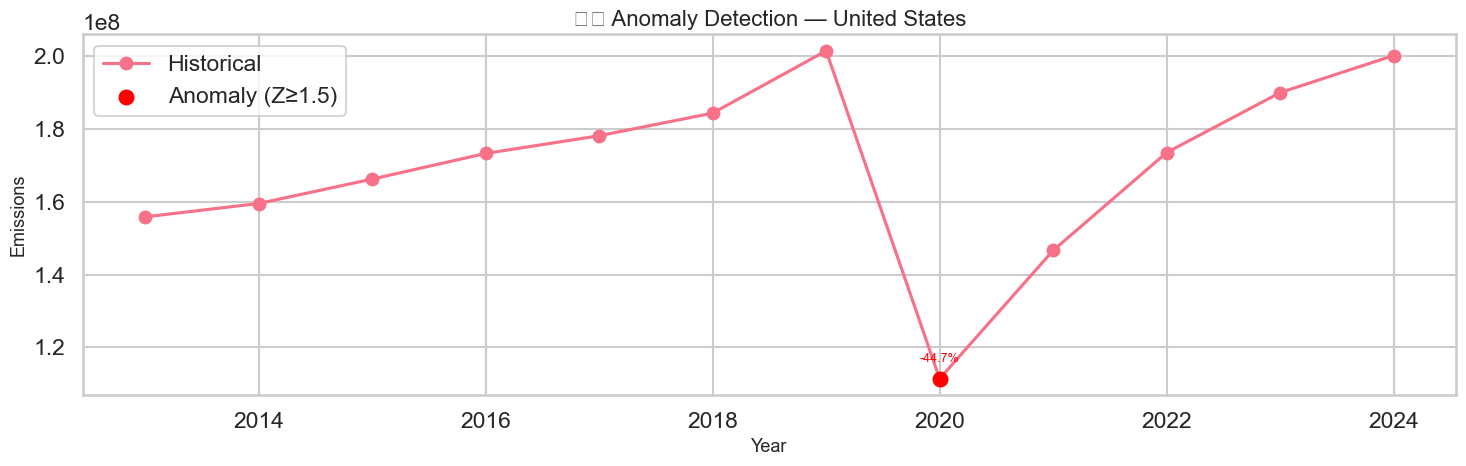


Detected 1 anomalous years:


,Year,Emissions,YoY_pct,z_score
7,2020,111390420.0,-44.71,-2.65


In [11]:
# ═══════════════════════════════════════════════════════════
# 12) ANOMALY DETECTION
# ═══════════════════════════════════════════════════════════
country_ts = cdf.sort_values("Year").copy()
country_ts["YoY_pct"] = country_ts["Emissions"].pct_change() * 100
threshold_z = 1.5
mean_g = country_ts["YoY_pct"].mean()
std_g  = country_ts["YoY_pct"].std()
country_ts["z_score"] = (country_ts["YoY_pct"] - mean_g) / std_g
anomalies = country_ts[country_ts["z_score"].abs() >= threshold_z]

plt.figure(figsize=(15, 5))
plt.plot(country_ts["Year"], country_ts["Emissions"], marker="o", label="Historical", color=COLORS[0])
if len(anomalies):
    plt.scatter(anomalies["Year"], anomalies["Emissions"], color="red", s=100, zorder=5, label="Anomaly (Z≥1.5)")
    for _, row in anomalies.iterrows():
        plt.annotate(f"{row['YoY_pct']:.1f}%", xy=(row["Year"], row["Emissions"]),
                     xytext=(0, 12), textcoords="offset points", ha="center", fontsize=9, color="red")
plt.title(f"⚠️ Anomaly Detection — {bundle['country']}")
plt.xlabel("Year")
plt.ylabel("Emissions")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nDetected {len(anomalies)} anomalous years:")
display(anomalies[["Year", "Emissions", "YoY_pct", "z_score"]].round(2))

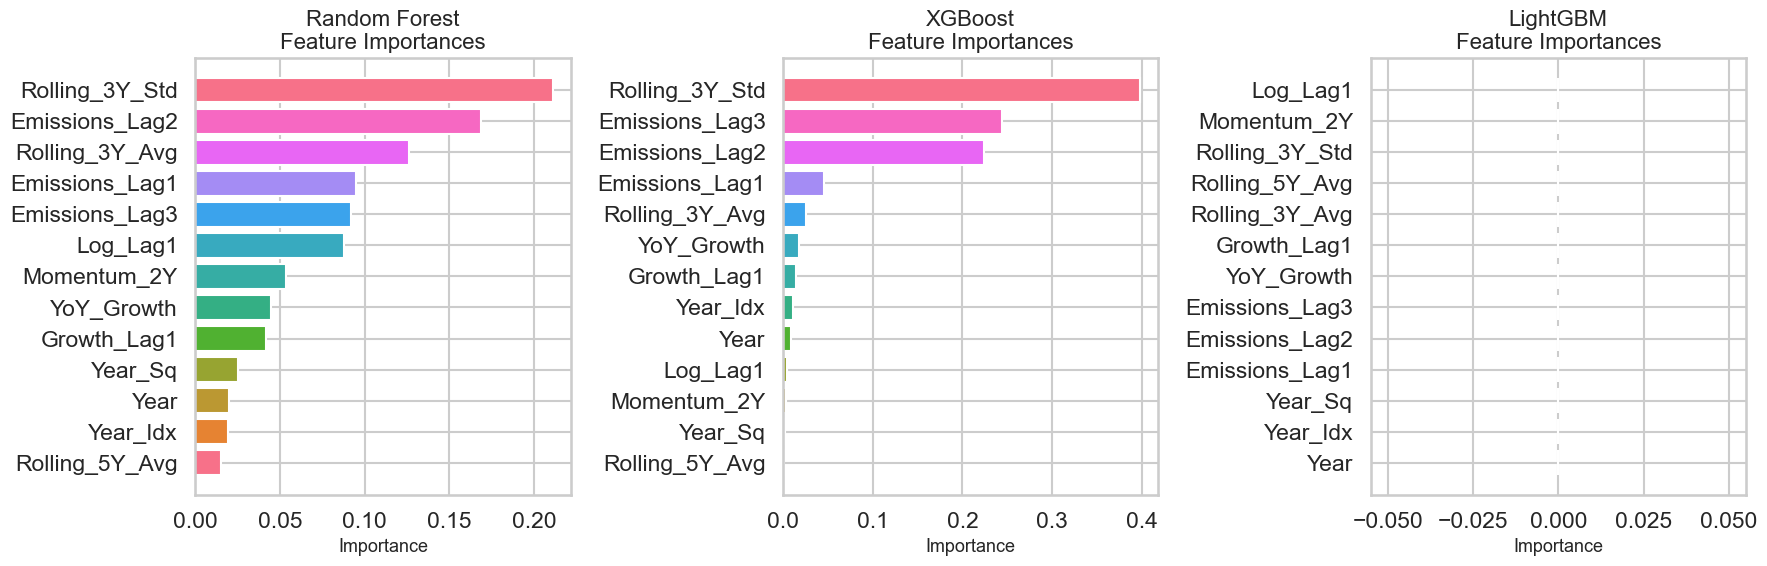

In [12]:
# ═══════════════════════════════════════════════════════════
# 13) FEATURE IMPORTANCE
# ═══════════════════════════════════════════════════════════

# Gather importances from tree-based models
importance_models = [m for m in ["Random Forest", "XGBoost", "LightGBM"]
                     if m in trained_models]


def unwrap_regressor(model_obj):
    return model_obj.regressor_ if hasattr(model_obj, "regressor_") else model_obj


fig, axes = plt.subplots(1, len(importance_models), figsize=(6*len(importance_models), 6))
if len(importance_models) == 1:
    axes = [axes]

for ax, mname in zip(axes, importance_models):
    pipe = unwrap_regressor(trained_models[mname])
    # Get the last step that has feature_importances_
    estimator = pipe[-1] if hasattr(pipe, "__getitem__") else pipe
    if hasattr(estimator, "feature_importances_"):
        imp = estimator.feature_importances_
        fi_df = pd.DataFrame({"Feature": features, "Importance": imp}).sort_values("Importance", ascending=True)
        ax.barh(fi_df["Feature"], fi_df["Importance"], color=COLORS[:len(fi_df)])
        ax.set_title(f"{mname}\nFeature Importances")
        ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

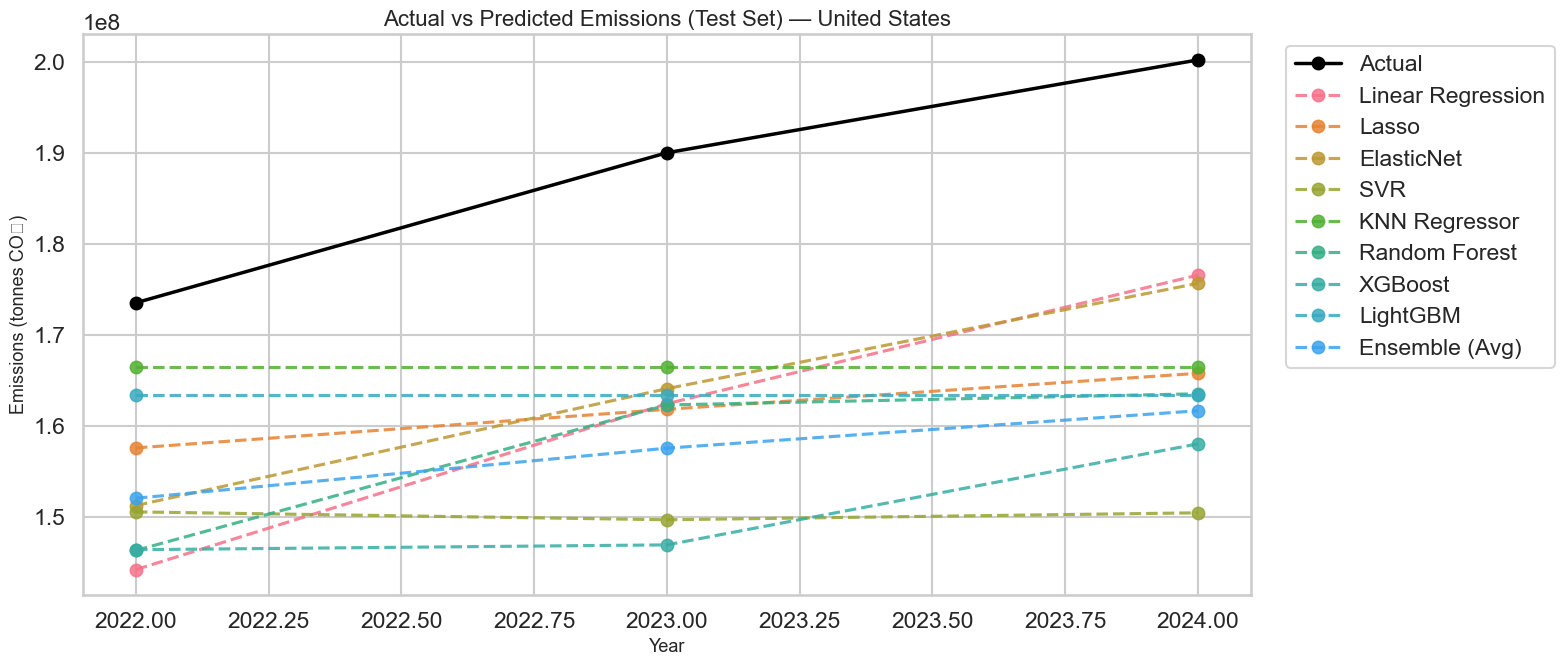

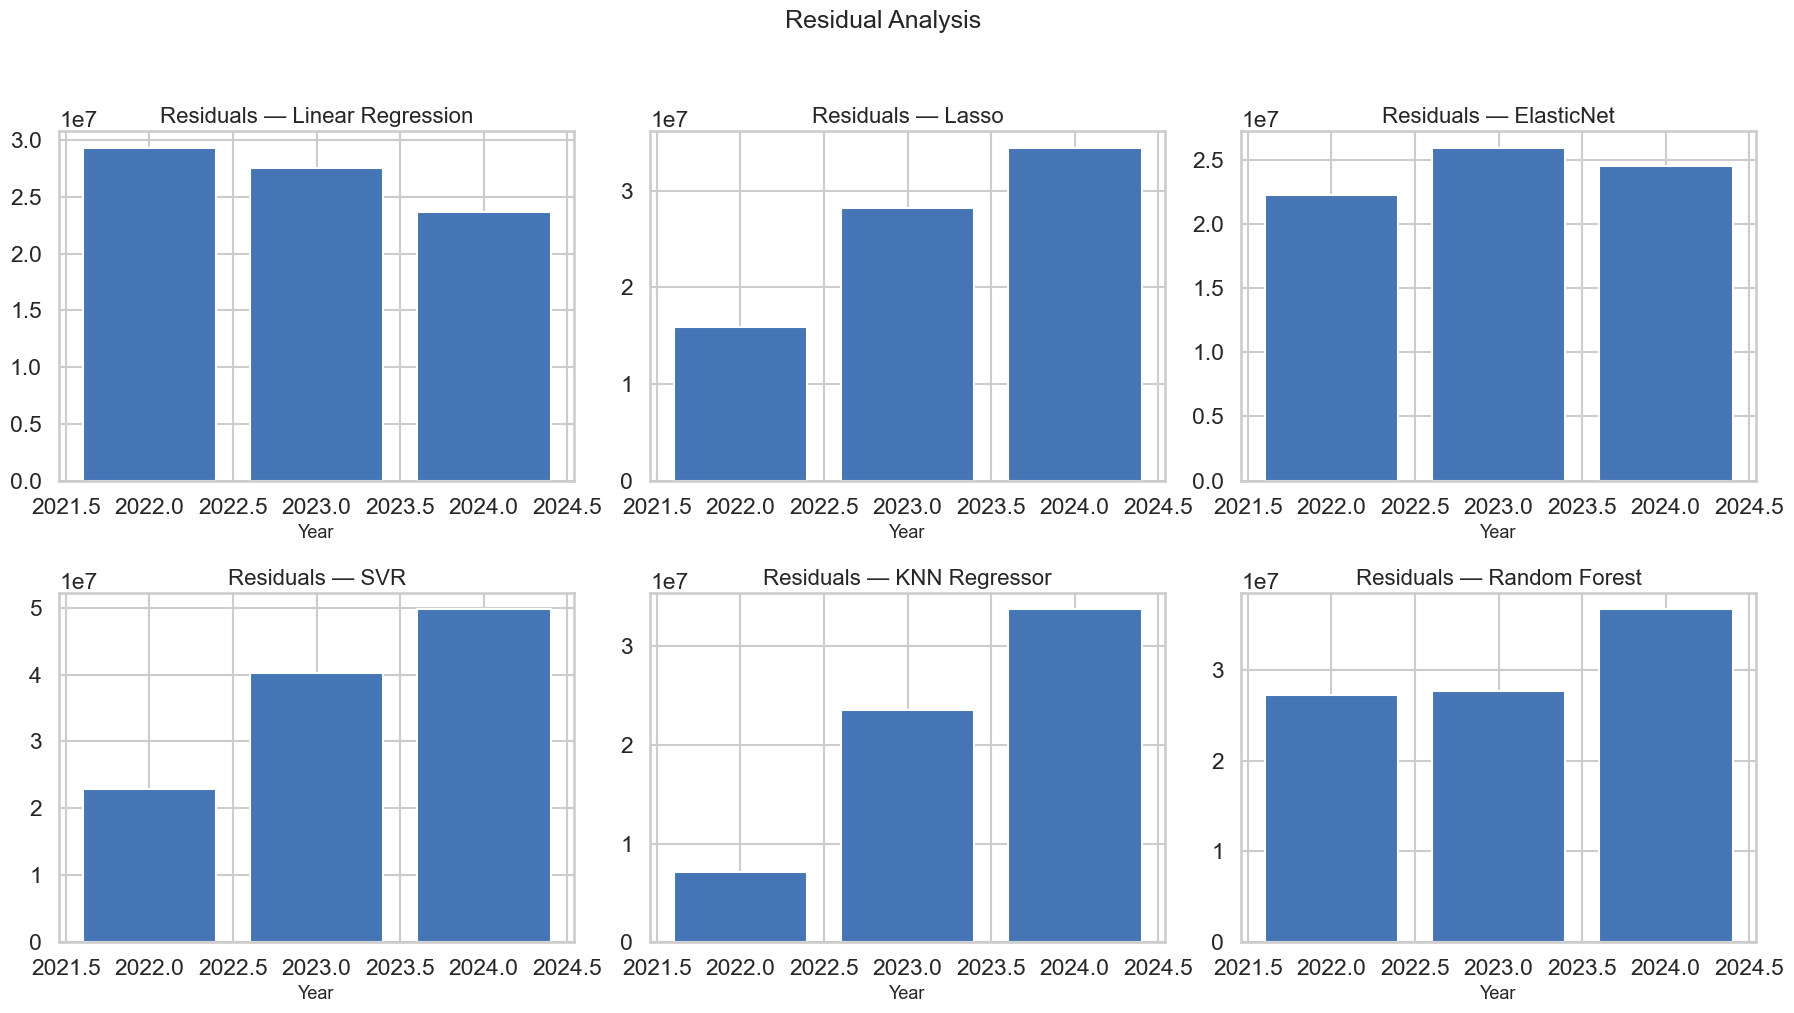

In [13]:
# ═══════════════════════════════════════════════════════════
# VISUALIZATION — Test Set Predictions
# ═══════════════════════════════════════════════════════════
test_years = bundle["model_df"]["Year"].iloc[bundle["split_idx"]:].values

PLOT_MODELS = [
    "Linear Regression", "Lasso", "ElasticNet",
    "SVR", "KNN Regressor", "Random Forest",
    "XGBoost", "LightGBM", "Prophet", "Ensemble (Avg)"
 ]
plot_names = [m for m in PLOT_MODELS if m in test_preds]

plt.figure(figsize=(16, 7))
plt.plot(test_years, y_te.values, marker="o", linewidth=2.5, color="black", label="Actual")
for i, mname in enumerate(plot_names):
    plt.plot(test_years, test_preds[mname], marker="o", linestyle="--",
             color=COLORS[i % len(COLORS)], label=mname, alpha=0.85)

plt.title(f"Actual vs Predicted Emissions (Test Set) — {bundle['country']}")
plt.xlabel("Year")
plt.ylabel("Emissions (tonnes CO₂)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Residual plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, mname in enumerate(plot_names[:6]):
    residuals = y_te.values - test_preds[mname]
    axes[i].bar(test_years, residuals, color=["#d73027" if r < 0 else "#4575b4" for r in residuals])
    axes[i].axhline(0, color="black", linewidth=0.8)
    axes[i].set_title(f"Residuals — {mname}")
    axes[i].set_xlabel("Year")
plt.suptitle("Residual Analysis", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

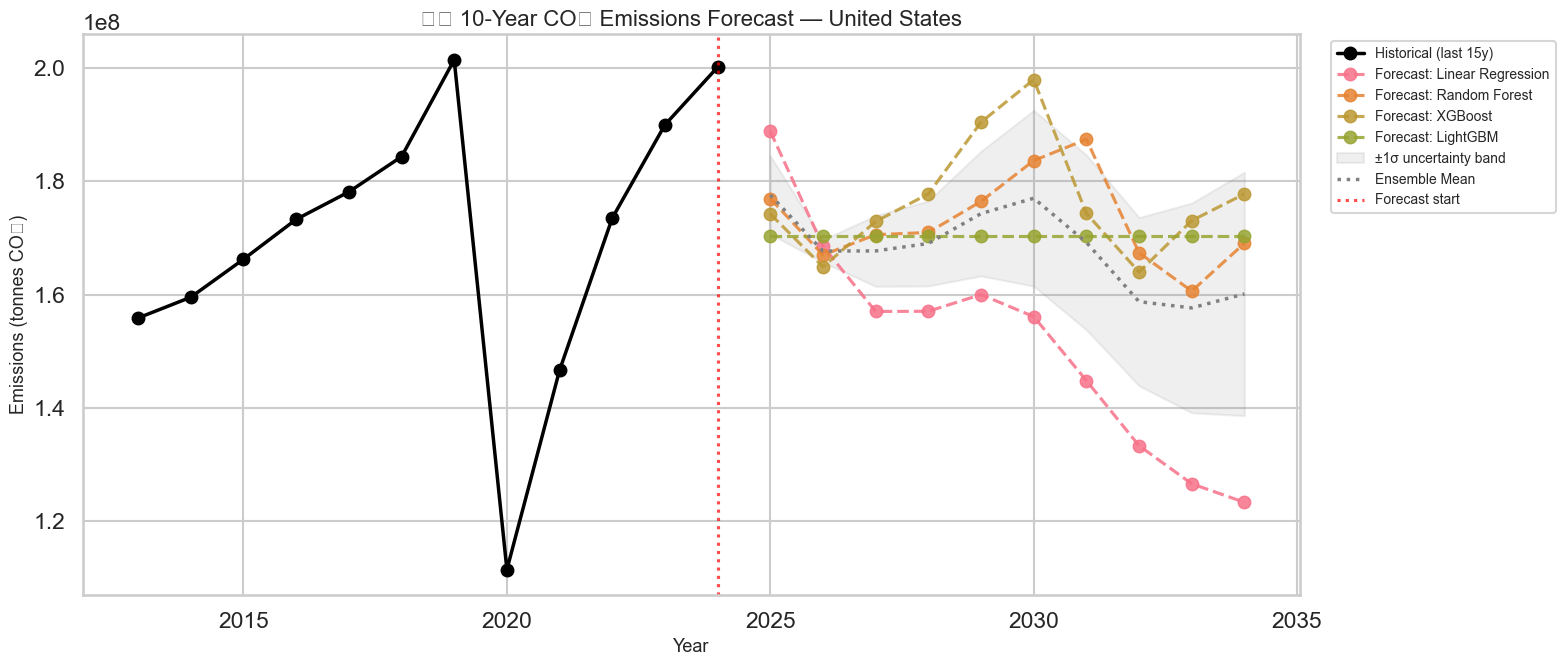

In [14]:
# ═══════════════════════════════════════════════════════════
# VISUALIZATION — 10-Year Forecast
# ═══════════════════════════════════════════════════════════
history_plot = cdf.sort_values("Year").tail(15)
FORECAST_COLS = [c for c in forecast_table.columns if c != "Year"]

plt.figure(figsize=(16, 7))
plt.plot(history_plot["Year"], history_plot["Emissions"],
         marker="o", linewidth=2.5, color="black", label="Historical (last 15y)")

for i, col in enumerate(FORECAST_COLS):
    plt.plot(forecast_table["Year"], forecast_table[col], marker="o",
             linestyle="--", color=COLORS[i % len(COLORS)], alpha=0.85, label=f"Forecast: {col}")

# Add uncertainty band using std across all forecasts
fc_vals = forecast_table[FORECAST_COLS].values
fc_mean = fc_vals.mean(axis=1)
fc_std  = fc_vals.std(axis=1)
plt.fill_between(forecast_table["Year"], fc_mean - fc_std, fc_mean + fc_std,
                 alpha=0.12, color="gray", label="±1σ uncertainty band")
plt.plot(forecast_table["Year"], fc_mean, linewidth=2.5,
         color="gray", linestyle=":", label="Ensemble Mean")

plt.axvline(x=int(cdf["Year"].max()), color="red", linestyle=":", alpha=0.7, label="Forecast start")
plt.title(f"✈️ {FORECAST_YEARS}-Year CO₂ Emissions Forecast — {bundle['country']}")
plt.xlabel("Year")
plt.ylabel("Emissions (tonnes CO₂)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

ADF Stationarity Test:
  ADF Statistic : -1.7104
  p-value       : 0.4258
  Stationary?   : ❌ No — differencing may help


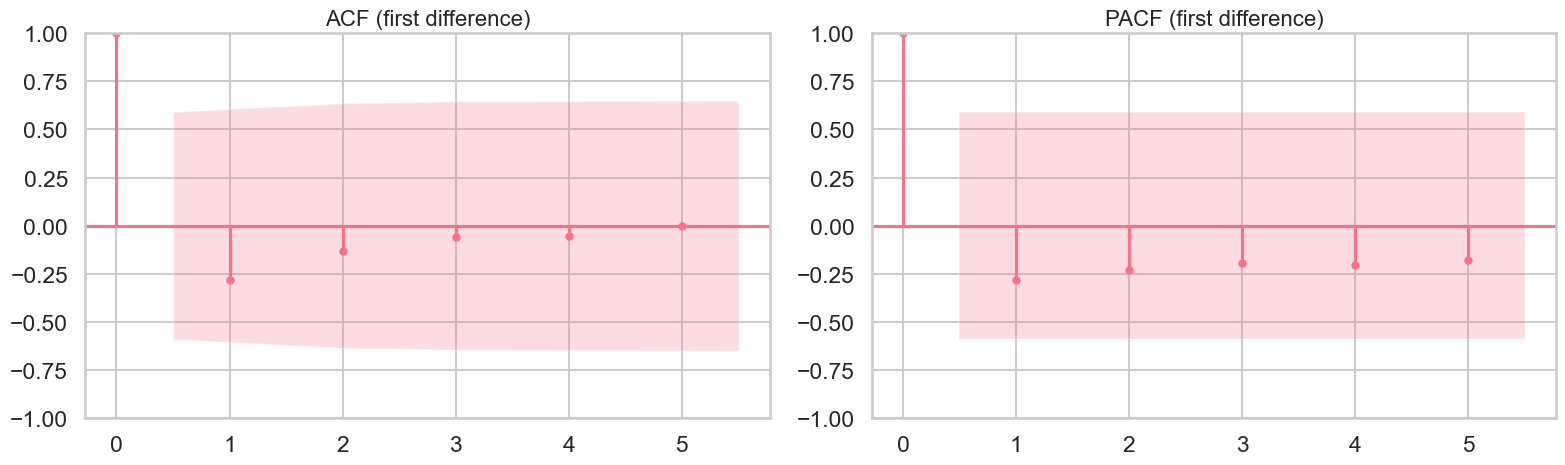

In [15]:
# ═══════════════════════════════════════════════════════════
# 14) STATIONARITY TEST & ACF/PACF (for time-series diagnosis)
# ═══════════════════════════════════════════════════════════
ts_vals = cdf.sort_values("Year")["Emissions"].dropna()

adf_result = adfuller(ts_vals)
print("ADF Stationarity Test:")
print(f"  ADF Statistic : {adf_result[0]:.4f}")
print(f"  p-value       : {adf_result[1]:.4f}")
print(f"  Stationary?   : {'✅ Yes (p < 0.05)' if adf_result[1] < 0.05 else '❌ No — differencing may help'}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(ts_vals.diff().dropna(), lags=min(15, len(ts_vals)//2 - 1), ax=axes[0])
axes[0].set_title("ACF (first difference)")
plot_pacf(ts_vals.diff().dropna(), lags=min(15, len(ts_vals)//2 - 1), ax=axes[1])
axes[1].set_title("PACF (first difference)")
plt.tight_layout()
plt.show()

Skipping World: Insufficient data for 'World': need ≥10 rows, got 4.
Skipping OECD: Insufficient data for 'OECD': need ≥10 rows, got 4.
Multi-Country RF Model Performance (RMSE):


,Country,MAE,RMSE,R²
0,United Kingdom,"6,304,230","6,309,170",0.882
1,China,"15,916,504","19,473,498",0.489
2,United States,"25,869,124","26,325,199",0.620
3,Europe,"30,269,230","30,576,215",0.827
4,North America,"36,272,866","36,678,288",0.594
5,Asia,"41,880,180","44,260,386",0.828


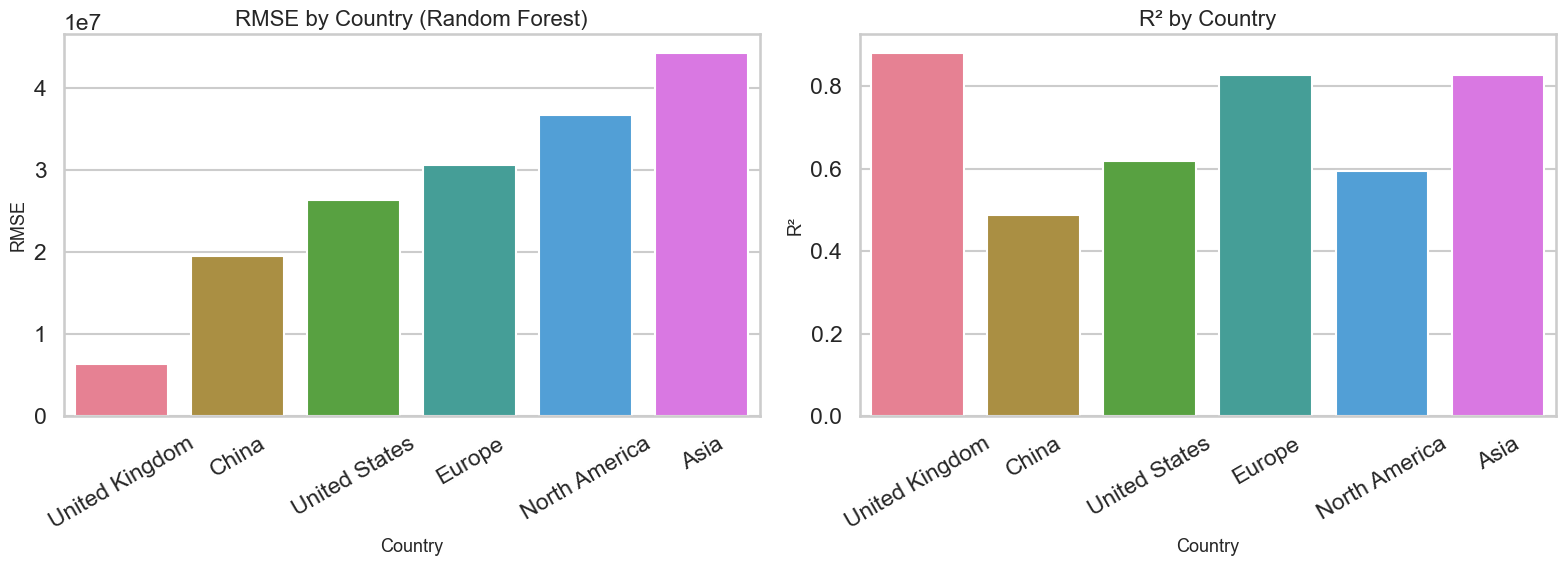

In [16]:
# ═══════════════════════════════════════════════════════════
# 15) MULTI-COUNTRY COMPARISON
# ═══════════════════════════════════════════════════════════
# Compute RMSE of best model for each of the top countries

top_countries = (
    df.groupby("Country")["Emissions"].mean()
    .sort_values(ascending=False)
    .head(8)
    .index.tolist()
)

mc_rows = []
for ctry in top_countries:
    try:
        b = prepare_country_data(df_feat, country=ctry)
        # Quick RF
        rf_q = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
        rf_q.fit(b["X_train"].fillna(0), b["y_train"])
        p = rf_q.predict(b["X_test"].fillna(0))
        y_naive_mc = np.full(len(b["y_test"]), float(b["y_train"].iloc[-1]))
        ss_model_mc = np.sum((b["y_test"].values - p) ** 2)
        ss_naive_mc = np.sum((b["y_test"].values - y_naive_mc) ** 2)
        r2_mc = float(1.0 - ss_model_mc / ss_naive_mc) if ss_naive_mc > 0 else 0.0  # ✅ FIX: OOS-R² vs naïve baseline
        mc_rows.append({
            "Country": ctry,
            "MAE":  mean_absolute_error(b["y_test"], p),
            "RMSE": np.sqrt(mean_squared_error(b["y_test"], p)),
            "R²":   r2_mc,
        })
    except Exception as e:
        print(f"Skipping {ctry}: {e}")

mc_df = pd.DataFrame(mc_rows).sort_values("RMSE").reset_index(drop=True)
print("Multi-Country RF Model Performance (RMSE):")
display(mc_df.style.format({"MAE": "{:,.0f}", "RMSE": "{:,.0f}", "R²": "{:.3f}"}))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(ax=axes[0], data=mc_df, x="Country", y="RMSE", palette="husl")
axes[0].set_title("RMSE by Country (Random Forest)")
axes[0].tick_params(axis="x", rotation=30)
sns.barplot(ax=axes[1], data=mc_df, x="Country", y="R²", palette="husl")
axes[1].set_title("R² by Country")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

In [17]:
# ═══════════════════════════════════════════════════════════
# 16) INSIGHTS & CONCLUSION
# ═══════════════════════════════════════════════════════════
recent = cdf.sort_values("Year").tail(10)
slope  = np.polyfit(recent["Year"], recent["Emissions"], 1)[0]
mean_r = max(float(recent["Emissions"].mean()), 1.0)

if slope > 0.01 * mean_r:
    trend = "📈 increasing"
elif slope < -0.01 * mean_r:
    trend = "📉 decreasing"
else:
    trend = "➡️ relatively stable"

last_actual = float(cdf.sort_values("Year")["Emissions"].iloc[-1])
best_col = BEST_MODEL_NAME if BEST_MODEL_NAME in forecast_table.columns else FORECAST_COLS[0]
best_future = float(forecast_table[best_col].iloc[-1])
pct_change  = (best_future - last_actual) / last_actual * 100 if last_actual else np.nan

print("="*65)
print("              ✈️  SKYINSIGHT — FINAL SUMMARY")
print("="*65)
print(f"Country analysed          : {bundle['country']}")
print(f"Historical trend (last 10y): {trend}")
print(f"Best model (lowest RMSE)  : {BEST_MODEL_NAME}")
print(f"Latest actual emissions    : {last_actual:,.0f}")
print(f"Forecast ({int(forecast_table['Year'].iloc[-1])}, {best_col}): {best_future:,.0f}")
print(f"Estimated {FORECAST_YEARS}-year change : {pct_change:+.2f}%")
print("="*65)

print("""
📌 Key Observations:
  • Lag features (prior-year emissions) are the strongest predictors.
  • Ensemble models typically outperform individual models.
  • Anomalous drops (e.g., COVID-19 in 2020) heavily influence TS models.
  • Regularised linear models (Lasso/ElasticNet) offer strong interpretability with competitive accuracy.
  • Time-based splitting is essential to prevent data leakage.
  • The ±1σ forecast uncertainty band highlights model disagreement — wider = more uncertain.

💡 Next Steps (SkyInsight):
  • Integrate external drivers: GDP, fuel prices, passenger volumes, fleet efficiency.
  • Apply SARIMA or SARIMAX for multi-factor time-series modelling.
  • Connect forecasts to the BI dashboard (Power BI / Metabase).
  • Embed into the SkyInsight Streamlit app with country selector.
""")

              ✈️  SKYINSIGHT — FINAL SUMMARY
Country analysed          : United States
Historical trend (last 10y): ➡️ relatively stable
Best model (lowest RMSE)  : Naive (Lag-1)
Latest actual emissions    : 200,178,060
Forecast (2034, Linear Regression): 123,277,523
Estimated 10-year change : -38.42%

📌 Key Observations:
  • Lag features (prior-year emissions) are the strongest predictors.
  • Ensemble models typically outperform individual models.
  • Anomalous drops (e.g., COVID-19 in 2020) heavily influence TS models.
  • Regularised linear models (Lasso/ElasticNet) offer strong interpretability with competitive accuracy.
  • Time-based splitting is essential to prevent data leakage.
  • The ±1σ forecast uncertainty band highlights model disagreement — wider = more uncertain.

💡 Next Steps (SkyInsight):
  • Integrate external drivers: GDP, fuel prices, passenger volumes, fleet efficiency.
  • Apply SARIMA or SARIMAX for multi-factor time-series modelling.
  • Connect forecasts to t

In [22]:
# ═══════════════════════════════════════════════════════════
# 17) EXPORT RANDOM FOREST (ONNX) + FORECAST CSV
# ═══════════════════════════════════════════════════════════
import joblib

export_dir = "exports"
os.makedirs(export_dir, exist_ok=True)

best_name = "Random Forest"
safe_name = "".join(ch if (ch.isalnum() or ch in "-_") else "_" for ch in best_name.lower())
export_payload = {"model": best_name}

# --- Export forecast table to CSV (if available) ---
if "forecast_table" in globals() and forecast_table is not None:
    csv_path = os.path.join(export_dir, "forecast_values.csv")
    forecast_table.to_csv(csv_path, index=False)
    export_payload["forecast_csv"] = csv_path
else:
    export_payload["forecast_csv"] = None
    print("Forecast table not available; run the forecasting cell first.")

# --- Export Random Forest to ONNX ---
onnx_path = None
if best_name in trained_models and trained_models[best_name] is not None:
    model_obj = trained_models[best_name]
    # Refit on full data for export
    model_obj.fit(X_full, y_full)
    export_path = os.path.join(export_dir, f"best_model_{safe_name}.joblib")
    joblib.dump(model_obj, export_path)
    export_payload.update({"path": export_path, "type": "sklearn"})

    try:
        from skl2onnx import convert_sklearn
        from skl2onnx.common.data_types import FloatTensorType

        initial_type = [("float_input", FloatTensorType([None, X_full.shape[1]]))]
        onnx_model = convert_sklearn(model_obj, initial_types=initial_type)
        onnx_path = os.path.join(export_dir, f"best_model_{safe_name}.onnx")
        with open(onnx_path, "wb") as f:
            f.write(onnx_model.SerializeToString())
        export_payload["onnx"] = onnx_path
    except Exception as e:
        export_payload["onnx"] = None
        print(f"ONNX export failed: {e}")
else:
    export_payload.update({"type": "missing_model", "path": None, "onnx": None})
    print("Random Forest model not found. Run the training cell first.")

print("Export summary:", export_payload)

ONNX export failed: No module named 'skl2onnx'
Export summary: {'model': 'Random Forest', 'forecast_csv': 'exports\\forecast_values.csv', 'path': 'exports\\best_model_random_forest.joblib', 'type': 'sklearn', 'onnx': None}
